# SVD-Based Movie Search Engine (Notebook)

This notebook recreates and explains the pipeline from `main.py` as a data science workflow:

1. Load movie data
2. Build text corpus
3. TF-IDF vectorization
4. SVD (LSA) projection
5. Cosine similarity search

Along the way, we visualize key parts of the model to understand how semantic search works.

In [1]:
# Uncomment this line if plotting libraries or notebook widgets are missing
# %pip install matplotlib pandas seaborn kagglehub ipywidgets -q

import os
import re
import ast
import glob
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Avoid noisy notebook widget warning from tqdm.auto when ipywidgets is unavailable.
warnings.filterwarnings('ignore', message='.*IProgress not found.*', category=Warning)
import kagglehub

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.preprocessing import Normalizer
from sklearn.pipeline import make_pipeline
from sklearn.metrics.pairwise import cosine_similarity

sns.set_theme(style='whitegrid')

## 1) Download From Kaggle and Inspect Dataset

This notebook now uses the Kaggle IMDb-v2 dataset (24 columns) instead of the synthetic JSON.

We explicitly map IMDb-v2 columns into a normalized schema for search:

- `id` <- `imdb_title_id`
- `title` <- `original_title` (fallback: `title`)
- `genre` <- `genre`
- `description` <- `description`
- `year` <- `year`
- `rating` <- `avg_vote`

This keeps the downstream SVD pipeline unchanged while using real IMDb data.

In [2]:
def _first_existing_column(df, candidates):
    for col in candidates:
        if col in df.columns:
            return col
    return None

def _parse_genres(value):
    if pd.isna(value):
        return ['Unknown']
    text = str(value).strip()
    if not text:
        return ['Unknown']
    parts = [p.strip() for p in re.split(r'\||,|/|;', text) if p.strip()]
    return parts if parts else ['Unknown']

def _parse_year(value):
    if pd.isna(value):
        return None
    text = str(value)
    match = re.search(r'(19\d{2}|20\d{2})', text)
    return int(match.group(1)) if match else None

def _parse_rating(value):
    if pd.isna(value):
        return np.nan
    try:
        return float(value)
    except (ValueError, TypeError):
        return np.nan

# Download latest version from Kaggle
dataset_path = kagglehub.dataset_download('chenyanglim/imdb-v2')
print('Path to dataset files:', dataset_path)

# Locate a tabular file
tabular_files = sorted(
    glob.glob(os.path.join(dataset_path, '*.csv'))
    + glob.glob(os.path.join(dataset_path, '*.tsv'))
    + glob.glob(os.path.join(dataset_path, '*.parquet'))
)
if not tabular_files:
    raise FileNotFoundError('No CSV/TSV/Parquet file found in downloaded Kaggle dataset.')

data_file = tabular_files[0]
print('Using file:', os.path.basename(data_file))

if data_file.endswith('.csv'):
    raw_df = pd.read_csv(data_file, low_memory=False)
elif data_file.endswith('.tsv'):
    raw_df = pd.read_csv(data_file, sep='\t', low_memory=False)
else:
    raw_df = pd.read_parquet(data_file)

print('Raw shape:', raw_df.shape)
print('Total columns:', raw_df.shape[1])
print('Columns:', list(raw_df.columns))

# IMDb-v2 specific priority mapping
id_col = _first_existing_column(raw_df, ['imdb_title_id', 'id'])
title_col = _first_existing_column(raw_df, ['original_title', 'title', 'movie_title', 'primaryTitle', 'name'])
genre_col = _first_existing_column(raw_df, ['genre', 'genres', 'Genre', 'listed_in'])
desc_col = _first_existing_column(raw_df, ['description', 'plot', 'overview', 'summary', 'synopsis', 'storyline'])
year_col = _first_existing_column(raw_df, ['year', 'release_year', 'startYear', 'released', 'release_date'])
rating_col = _first_existing_column(raw_df, ['avg_vote', 'rating', 'imdb_rating', 'vote_average', 'averageRating', 'imdb_score'])

print('Mapped columns:')
print(' id       ->', id_col)
print(' title    ->', title_col)
print(' genre    ->', genre_col)
print(' desc     ->', desc_col)
print(' year     ->', year_col)
print(' rating   ->', rating_col)

if title_col is None:
    raise ValueError('Could not identify a title column from Kaggle dataset.')

norm_df = pd.DataFrame({
    'id': raw_df[id_col].astype(str) if id_col else np.arange(1, len(raw_df) + 1),
    'title': raw_df[title_col].fillna('Unknown Title').astype(str),
    'genre': raw_df[genre_col].apply(_parse_genres) if genre_col else [['Unknown']] * len(raw_df),
    'description': raw_df[desc_col].fillna('').astype(str) if desc_col else '',
    'year': raw_df[year_col].apply(_parse_year) if year_col else None,
    'rating': raw_df[rating_col].apply(_parse_rating) if rating_col else np.nan,
})

# Fallback description if blank
norm_df['description'] = np.where(
    norm_df['description'].str.strip().eq(''),
    norm_df['title'],
    norm_df['description'],
)

# Keep rows with core fields and reset index
norm_df = norm_df.dropna(subset=['title']).reset_index(drop=True)

movies = norm_df.to_dict(orient='records')
df = norm_df.copy()

print('Number of movies after normalization:', len(df))
display(df.head(5))

Path to dataset files: /Users/horkimhouy/.cache/kagglehub/datasets/chenyanglim/imdb-v2/versions/3
Using file: IMDB Movies 2000 - 2020.csv
Raw shape: (5487, 24)
Total columns: 24
Columns: ['imdb_title_id', 'title', 'original_title', 'year', 'date_published', 'genre', 'duration', 'country', 'language_1', 'language_2', 'language_3', 'director', 'writer', 'actors', 'actors_1', 'actors_f2', 'description', 'desc35', 'avg_vote', 'votes', 'budget', 'usa_gross_income', 'worlwide_gross_income', 'reviews_from_users']
Mapped columns:
 id       -> imdb_title_id
 title    -> original_title
 genre    -> genre
 desc     -> description
 year     -> year
 rating   -> avg_vote
Number of movies after normalization: 5487


,id,title,genre,description,year,rating
0,tt0035423,Kate & Leopold,"[Comedy, Fantasy, Romance]",An English Duke from 1876 is inadvertedly drag...,2001,6.4
1,tt0118589,Glitter,"[Drama, Music, Romance]",A young singer dates a disc jockey who helps h...,2001,2.2
2,tt0118694,Fa yeung nin wah,"[Drama, Romance]","Two neighbors, a woman and a man, form a stron...",2000,8.1
3,tt0120202,State and Main,"[Comedy, Drama]",A movie crew invades a small town whose reside...,2000,6.7
4,tt0120263,Sånger från andra våningen,"[Comedy, Drama]",Where are we humans going? A film poem inspire...,2000,7.6


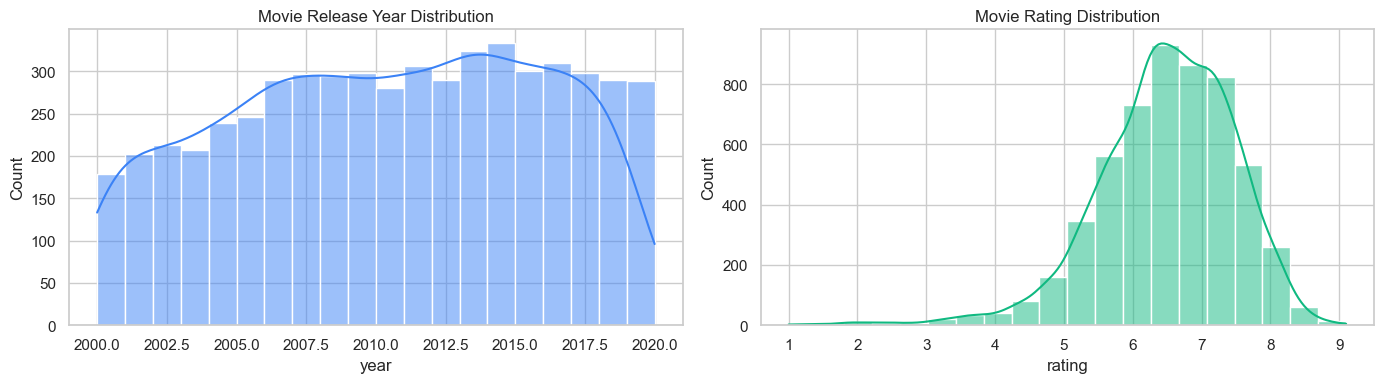

In [3]:
# Basic exploratory visualizations
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df['year'], bins=20, kde=True, ax=axes[0], color='#3B82F6')
axes[0].set_title('Movie Release Year Distribution')

sns.histplot(df['rating'], bins=20, kde=True, ax=axes[1], color='#10B981')
axes[1].set_title('Movie Rating Distribution')

plt.tight_layout()
plt.show()

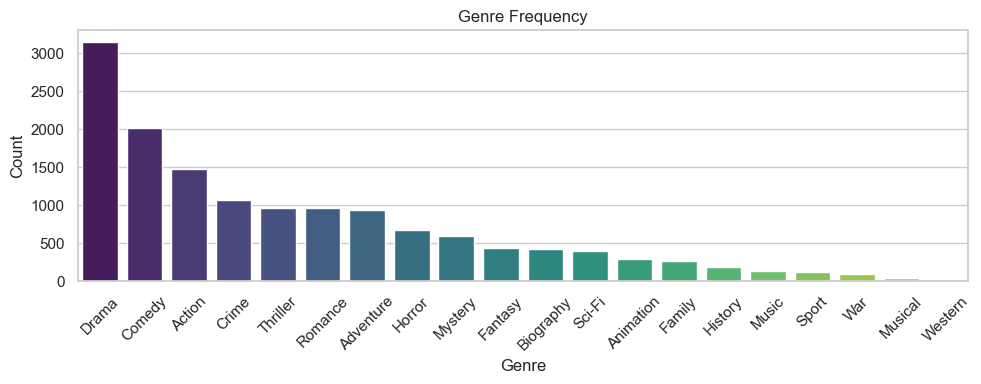

In [10]:
# Genre frequency (multi-label)
genre_counts = df['genre'].explode().value_counts()

plt.figure(figsize=(10, 4))
sns.barplot(x=genre_counts.index, y=genre_counts.values, hue=genre_counts.index, palette='viridis', legend=False)
plt.title('Genre Frequency')
plt.xlabel('Genre')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 2) Build Corpus

Like `main.py`, we combine each movie's `title + genre + description` into one text document.

This gives the search engine richer context than title-only search.

In [7]:
def build_corpus(movies):
    corpus = []
    for m in movies:
        text = m['title'] + ' ' + ' '.join(m['genre']) + ' ' + m['description']
        corpus.append(text.lower())
    return corpus

corpus = build_corpus(movies)
print('Corpus size:', len(corpus))
print('Sample document:\n')
print(corpus[0])

Corpus size: 5487
Sample document:

kate & leopold comedy fantasy romance an english duke from 1876 is inadvertedly dragged to modern day new york where he falls for a plucky advertising executive.


## 3) TF-IDF Vectorization

TF-IDF converts text to a sparse matrix where each column is a token and each value represents token importance in a movie document.

In [8]:
tfidf = TfidfVectorizer(stop_words='english')
X_tfidf = tfidf.fit_transform(corpus)

print('TF-IDF matrix shape:', X_tfidf.shape)
print('Sparsity (% zeros):', round((1 - X_tfidf.nnz / (X_tfidf.shape[0] * X_tfidf.shape[1])) * 100, 2))

TF-IDF matrix shape: (5487, 16735)
Sparsity (% zeros): 99.89


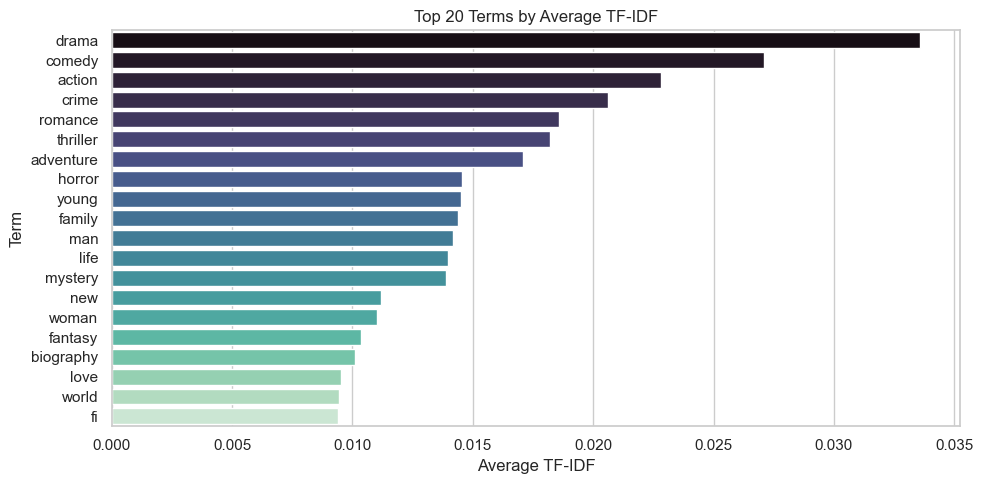

In [14]:
# Top tokens by average TF-IDF score
feature_names = np.array(tfidf.get_feature_names_out())
avg_tfidf = np.asarray(X_tfidf.mean(axis=0)).ravel()
top_idx = np.argsort(avg_tfidf)[-20:][::-1]

plt.figure(figsize=(10, 5))
sns.barplot(x=avg_tfidf[top_idx], y=feature_names[top_idx], hue=feature_names[top_idx], palette='mako', legend=False)
plt.title('Top 20 Terms by Average TF-IDF')
plt.xlabel('Average TF-IDF')
plt.ylabel('Term')
plt.tight_layout()
plt.show()

## 4) SVD / LSA Projection

SVD reduces the high-dimensional TF-IDF space into a lower-dimensional latent semantic space.

In `main.py`, the model also caps `n_components` to valid matrix bounds.

In [13]:
def build_model(corpus, n_components=100):
    tfidf_local = TfidfVectorizer(stop_words='english')
    X_tfidf_local = tfidf_local.fit_transform(corpus)

    max_components = min(X_tfidf_local.shape[0] - 1, X_tfidf_local.shape[1] - 1)
    n_components = min(n_components, max_components)

    svd = TruncatedSVD(n_components=n_components, random_state=42)
    normalizer = Normalizer(copy=False)
    lsa = make_pipeline(svd, normalizer)

    X_lsa_local = lsa.fit_transform(X_tfidf_local)
    return tfidf_local, lsa, X_lsa_local, svd

tfidf, lsa, X_lsa, svd = build_model(corpus, n_components=100)
print('LSA matrix shape:', X_lsa.shape)

LSA matrix shape: (5487, 100)


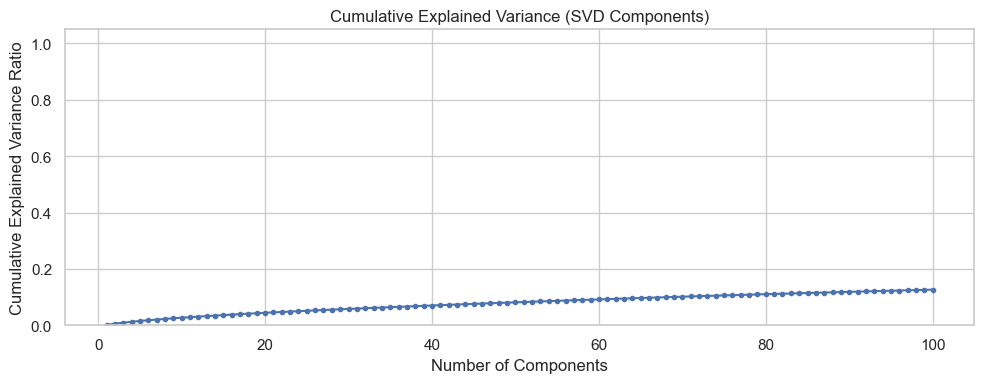

Explained variance with 100 components: 0.1261


In [15]:
# Explained variance by latent components
explained = svd.explained_variance_ratio_
cum_explained = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.plot(range(1, len(cum_explained) + 1), cum_explained, marker='o', markersize=3)
plt.title('Cumulative Explained Variance (SVD Components)')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance Ratio')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

print('Explained variance with 100 components:', round(float(cum_explained[-1]), 4))

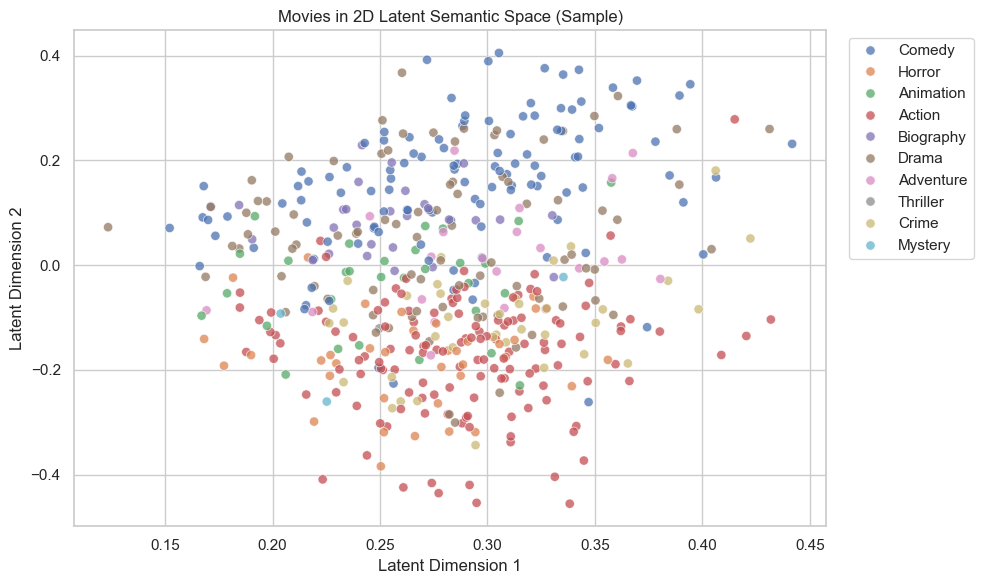

In [16]:
# 2D semantic view using first two latent dimensions
plot_df = pd.DataFrame({
    'dim1': X_lsa[:, 0],
    'dim2': X_lsa[:, 1],
    'genre': df['genre'].apply(lambda g: g[0] if isinstance(g, list) and len(g) else 'Unknown')
})

plt.figure(figsize=(10, 6))
sns.scatterplot(data=plot_df.sample(min(500, len(plot_df)), random_state=42), x='dim1', y='dim2', hue='genre', alpha=0.75, s=45)
plt.title('Movies in 2D Latent Semantic Space (Sample)')
plt.xlabel('Latent Dimension 1')
plt.ylabel('Latent Dimension 2')
plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 5) Query Search with Cosine Similarity

A user query is transformed into TF-IDF, projected into LSA space, then compared to movie vectors with cosine similarity.

Formula:

$$\text{similarity}(A, B) = \frac{A \cdot B}{\|A\|\|B\|}$$

In [17]:
def search(query, tfidf_model, lsa_model, X_lsa_matrix, movies_data, top_k=5):
    query_vec = tfidf_model.transform([query])
    query_lsa = lsa_model.transform(query_vec)

    similarities = cosine_similarity(query_lsa, X_lsa_matrix)[0]
    top_indices = np.argsort(similarities)[::-1][:top_k]

    results = []
    for idx in top_indices:
        m = movies_data[idx]
        results.append({
            'title': m['title'],
            'genre': ', '.join(m['genre']),
            'year': m['year'],
            'rating': m['rating'],
            'score': float(similarities[idx])
        })
    return pd.DataFrame(results)

query = 'black cop'
result_df = search(query, tfidf, lsa, X_lsa, movies, top_k=10)
print('Query:', query)
display(result_df)

Query: black cop


,title,genre,year,rating,score
0,Saaho,"Action, Thriller",2019,5.2,0.772434
1,Mou gaan dou,"Action, Crime, Drama",2002,8.0,0.683278
2,Sinsegye,"Action, Crime, Drama",2013,7.6,0.619271
3,"Bon Cop, Bad Cop","Action, Comedy, Crime",2006,6.8,0.606681
4,Little Black Book,"Comedy, Romance, Drama",2004,5.3,0.593518
5,The Departed,"Crime, Drama, Thriller",2006,8.5,0.588493
6,Dookudu,"Action, Comedy",2011,7.4,0.553161
7,Mou gaan dou II,"Action, Crime, Drama",2003,7.3,0.543156
8,Showtime,"Action, Comedy, Crime",2002,5.5,0.528815
9,The Black Dahlia,"Crime, Drama, Mystery",2006,5.6,0.515703


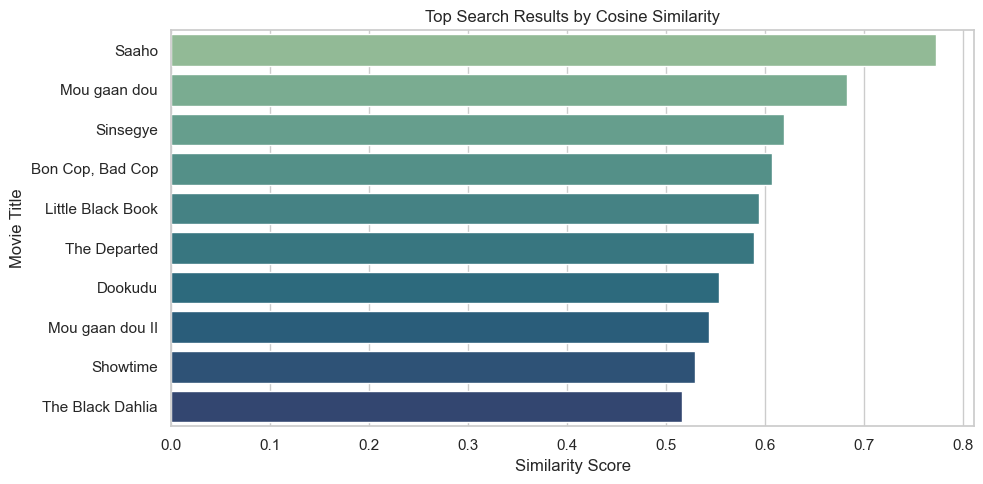

In [18]:
# Visualize similarity scores for the current query
plt.figure(figsize=(10, 5))
sns.barplot(data=result_df, y='title', x='score', hue='title', palette='crest', dodge=False, legend=False)
plt.title('Top Search Results by Cosine Similarity')
plt.xlabel('Similarity Score')
plt.ylabel('Movie Title')
plt.tight_layout()
plt.show()

## 6) Quick Multi-Query Comparison

This lets you test semantic behavior across different query intents.

In [19]:
queries = [
    'space mission',
    'love story romance',
    'mysterious detective case',
    'terrifying threat friends'
]

for q in queries:
    top3 = search(q, tfidf, lsa, X_lsa, movies, top_k=3)
    print('\n' + '=' * 80)
    print('Query:', q)
    display(top3[['title', 'genre', 'score']])


Query: space mission


,title,genre,score
0,Mission: Impossible - Rogue Nation,"Action, Adventure, Thriller",0.790612
1,Mission to Mars,"Adventure, Sci-Fi, Thriller",0.776244
2,Mission Mangal,"Drama, History",0.769503



Query: love story romance


,title,genre,score
0,Love Aaj Kal,"Comedy, Drama, Romance",0.831269
1,Veer-Zaara,"Drama, Family, Musical",0.783447
2,Les amours imaginaires,"Drama, Romance",0.783062



Query: mysterious detective case


,title,genre,score
0,Di renjie: Tong tian di guo,"Action, Adventure, Drama",0.776395
1,The Medallion,"Action, Comedy, Fantasy",0.695607
2,Hollywoodland,"Biography, Crime, Drama",0.680710



Query: terrifying threat friends


,title,genre,score
0,Desi Boyz,"Comedy, Drama",0.812744
1,Zindagi Na Milegi Dobara,"Comedy, Drama",0.802857
2,The Romantics,"Comedy, Drama, Romance",0.744758


## 7) Summary

You now have a full notebook version of the SVD search engine with interpretability plots.

Key takeaways:
- TF-IDF encodes term importance
- SVD compresses sparse lexical space into latent semantic dimensions
- Cosine similarity ranks semantically related movies

This approach is efficient and explainable, and serves as a strong baseline for semantic retrieval.